In [4]:
import random
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# 2) Model definition
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 10, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(10, 20, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(320, 50),
            nn.ReLU(),
            nn.Linear(50, 10),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# 3) Train/Validation/Test helpers
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=5, patience=2):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )


    return history


# 4) Data setup (Train/Validation/Test)
BATCH_SIZE = 128
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
VAL_RATIO = 0.1


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

val_size = int(len(full_train_dataset) * VAL_RATIO)
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
)

pin_memory = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)

print(
    f"Dataset sizes -> Train: {len(train_dataset)}, "
    f"Validation: {len(val_dataset)}, Test: {len(test_dataset)}"
)


# 5) Train and evaluate
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=NUM_EPOCHS,
    patience=2,
)

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nFinal Test Loss: {test_loss:.4f} | Final Test Accuracy: {test_acc:.4f}")

Using device: mps
Dataset sizes -> Train: 54000, Validation: 6000, Test: 10000
Epoch 01/5 | Train Loss: 0.3430 | Train Acc: 0.9030 | Val Loss: 0.1186 | Val Acc: 0.9632
Epoch 02/5 | Train Loss: 0.0855 | Train Acc: 0.9746 | Val Loss: 0.0736 | Val Acc: 0.9750
Epoch 03/5 | Train Loss: 0.0617 | Train Acc: 0.9812 | Val Loss: 0.0639 | Val Acc: 0.9780
Epoch 04/5 | Train Loss: 0.0483 | Train Acc: 0.9853 | Val Loss: 0.0516 | Val Acc: 0.9837
Epoch 05/5 | Train Loss: 0.0398 | Train Acc: 0.9877 | Val Loss: 0.0489 | Val Acc: 0.9832

Final Test Loss: 0.0395 | Final Test Accuracy: 0.9870


In [5]:
# Verify model on test dataset
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []
running_loss = 0.0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_loss = running_loss / total
test_accuracy = (all_preds == all_labels).mean()

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

Test Loss: 0.0395
Test Accuracy: 98.7000%

Confusion Matrix:
[[ 977    0    0    0    0    0    1    1    1    0]
 [   1 1124    1    0    0    1    4    0    4    0]
 [   6    1 1011    2    1    0    2    5    4    0]
 [   2    0    0 1003    0    2    0    2    1    0]
 [   1    0    0    0  971    0    1    0    2    7]
 [   1    0    0    4    0  882    1    1    1    2]
 [   7    1    0    0    2    4  942    0    2    0]
 [   0    3    3    2    1    0    0 1014    1    4]
 [   4    0    1    0    0    1    1    1  965    1]
 [   4    1    0    3    4    5    0    5    6  981]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9741    0.9969    0.9854       980
           1     0.9947    0.9903    0.9925      1135
           2     0.9951    0.9797    0.9873      1032
           3     0.9892    0.9931    0.9911      1010
           4     0.9918    0.9888    0.9903       982
           5     0.9855    0.9888    0.9871       892
     

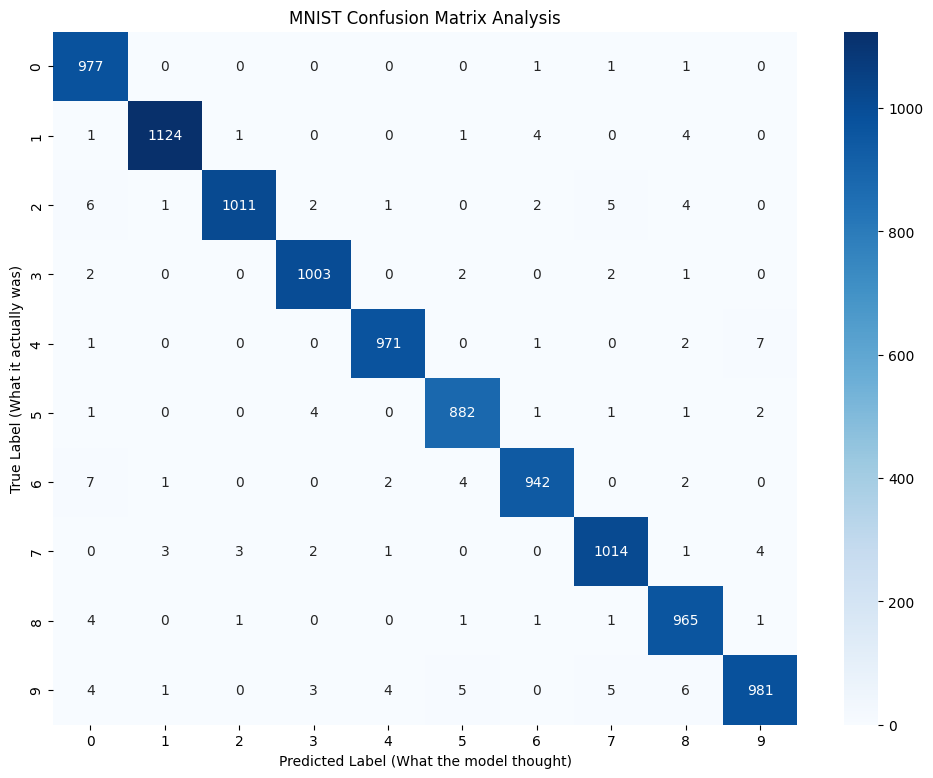

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Input your confusion matrix data
data = confusion_matrix(all_labels, all_preds)

# 2. Convert to DataFrame for better labeling
df_cm = pd.DataFrame(data, index=[i for i in range(10)],
                     columns=[i for i in range(10)])

# 3. Create Heatmap
plt.figure(figsize=(12, 9))
# 'annot=True' displays numbers in cells
# 'fmt="d"' ensures integers are shown correctly
# 'cmap="Blues"' sets the color gradient
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True)

plt.title("MNIST Confusion Matrix Analysis")
plt.xlabel("Predicted Label (What the model thought)")
plt.ylabel("True Label (What it actually was)")
plt.show()

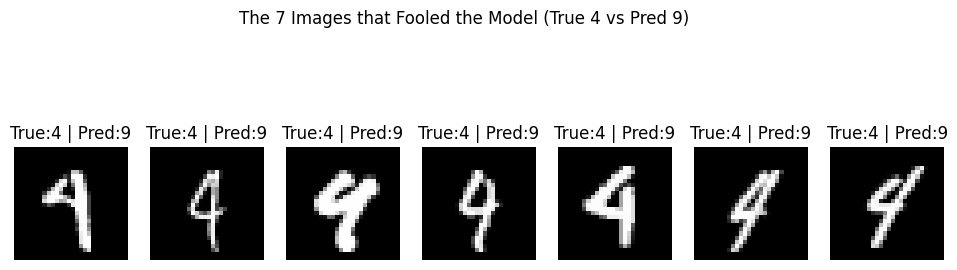

In [ ]:
#Hard Example Mining
import matplotlib.pyplot as plt
import torch

# 1. Initialize storage for misclassified images
misclassified_images = []
true_label_target = 4
pred_label_target = 9

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        preds = output.argmax(dim=1)
        
        # 2. Find indices where True is 4 but Pred is 9
        mask = (labels == true_label_target) & (preds == pred_label_target)
        
        if mask.any():
            # Get the actual image data
            items = images[mask].cpu()
            misclassified_images.extend(items)
            
        # Stop if we found all 7 instances (based on your confusion matrix)
        if len(misclassified_images) >= 7:
            break

# 3. Plotting the 'Culprits'
plt.figure(figsize=(12, 4))
for i, img in enumerate(misclassified_images[:7]):
    plt.subplot(1, 7, i + 1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"True:4 | Pred:9")

plt.suptitle("The Images that Fooled the Model (True 4 vs Pred 9)")
plt.show()